# Credit Risk Analysis - Feature Engineering
## Week 1: Creating Predictive Features

### Objectives:
1. Handle missing values (domain-aware imputation)
2. Create derived features
3. Feature scaling and transformation
4. Handle outliers
5. Prepare train/test split (stratified)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Dataset

In [2]:
# Load the raw data
df = pd.read_csv('../data/raw/cs-training.csv', index_col=0)

print(f"Original dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Original dataset shape: (150000, 11)

Columns: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Store target variable
target_col = 'SeriousDlqin2yrs'
y = df[target_col].copy()

# Create feature set (without target)
X = df.drop(columns=[target_col]).copy()

print(f"Target distribution:\n{y.value_counts()}")
print(f"\nFeatures shape: {X.shape}")

Target distribution:
SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

Features shape: (150000, 10)


## 2. Handle Missing Values

### From EDA, we found missing values in:
- MonthlyIncome (~20% missing)
- NumberOfDependents (~3% missing)

### Strategy:
- **MonthlyIncome**: Impute with median (robust to outliers)
- **NumberOfDependents**: Impute with mode or median
- Create indicator features for missingness (might be predictive!)

In [4]:
# Check missing values
missing_summary = pd.DataFrame({
    'Column': X.columns,
    'Missing_Count': X.isnull().sum(),
    'Missing_Percentage': (X.isnull().sum() / len(X)) * 100
}).sort_values('Missing_Percentage', ascending=False)

missing_summary = missing_summary[missing_summary['Missing_Count'] > 0]
print("Missing Values Before Imputation:")
print(missing_summary.to_string(index=False))

Missing Values Before Imputation:
            Column  Missing_Count  Missing_Percentage
     MonthlyIncome          29731           19.820667
NumberOfDependents           3924            2.616000


In [5]:
# Create missing value indicator features
# These can be predictive (e.g., people hiding income might be riskier)

X['MonthlyIncome_Missing'] = X['MonthlyIncome'].isnull().astype(int)
X['NumberOfDependents_Missing'] = X['NumberOfDependents'].isnull().astype(int)

print("Missing indicator features created:")
print(f"MonthlyIncome_Missing: {X['MonthlyIncome_Missing'].sum()} cases")
print(f"NumberOfDependents_Missing: {X['NumberOfDependents_Missing'].sum()} cases")

Missing indicator features created:
MonthlyIncome_Missing: 29731 cases
NumberOfDependents_Missing: 3924 cases


In [6]:
# Impute missing values
# Use median for MonthlyIncome (robust to outliers)
X['MonthlyIncome'].fillna(X['MonthlyIncome'].median(), inplace=True)

# Use median for NumberOfDependents (most people have 0-1 dependents)
X['NumberOfDependents'].fillna(X['NumberOfDependents'].median(), inplace=True)

# Verify no missing values remain
print("Missing values after imputation:")
print(X.isnull().sum().sum())
assert X.isnull().sum().sum() == 0, "Still have missing values!"
print("✓ All missing values handled!")

Missing values after imputation:
0
✓ All missing values handled!


## 3. Create Derived Features

### Credit Risk Domain Features:
1. **Total Delinquencies**: Sum of all late payment types
2. **Severe Delinquency**: Whether person has 90+ day late payments
3. **Credit Utilization Buckets**: Low/Medium/High utilization
4. **Age Groups**: Younger vs older borrowers
5. **Debt Burden**: Categorize debt ratio
6. **Income-to-Debt Ratio**: Better risk indicator

In [7]:
# 1. Total Delinquencies (sum of all late payment indicators)
X['TotalDelinquencies'] = (X['NumberOfTime30-59DaysPastDueNotWorse'] + 
                           X['NumberOfTime60-89DaysPastDueNotWorse'] + 
                           X['NumberOfTimes90DaysLate'])

print(f"TotalDelinquencies created - Range: {X['TotalDelinquencies'].min()} to {X['TotalDelinquencies'].max()}")
print(f"Mean: {X['TotalDelinquencies'].mean():.2f}")

TotalDelinquencies created - Range: 0 to 294
Mean: 0.93


In [8]:
# 2. Severe Delinquency Flag (has 90+ day late payments)
X['HasSevereDelinquency'] = (X['NumberOfTimes90DaysLate'] > 0).astype(int)

print(f"HasSevereDelinquency created:")
print(X['HasSevereDelinquency'].value_counts())
print(f"Percentage with severe delinquency: {X['HasSevereDelinquency'].mean()*100:.2f}%")

HasSevereDelinquency created:
HasSevereDelinquency
0    141662
1      8338
Name: count, dtype: int64
Percentage with severe delinquency: 5.56%


In [9]:
# 3. Credit Utilization Buckets
# 0-30%: Low risk, 30-70%: Medium risk, 70%+: High risk

def categorize_utilization(util):
    if util <= 0.30:
        return 0  # Low
    elif util <= 0.70:
        return 1  # Medium
    else:
        return 2  # High

X['UtilizationBucket'] = X['RevolvingUtilizationOfUnsecuredLines'].apply(categorize_utilization)

print("Credit Utilization Buckets:")
print(X['UtilizationBucket'].value_counts().sort_index())
print("\n0: Low (0-30%), 1: Medium (30-70%), 2: High (70%+)")

Credit Utilization Buckets:
UtilizationBucket
0    92882
1    27170
2    29948
Name: count, dtype: int64

0: Low (0-30%), 1: Medium (30-70%), 2: High (70%+)


In [10]:
# 4. Age Groups
# Young: <35, Middle: 35-55, Senior: 55+

def categorize_age(age):
    if age < 35:
        return 0  # Young
    elif age < 55:
        return 1  # Middle
    else:
        return 2  # Senior

X['AgeGroup'] = X['age'].apply(categorize_age)

print("Age Groups:")
print(X['AgeGroup'].value_counts().sort_index())
print("\n0: Young (<35), 1: Middle (35-55), 2: Senior (55+)")

Age Groups:
AgeGroup
0    19240
1    65339
2    65421
Name: count, dtype: int64

0: Young (<35), 1: Middle (35-55), 2: Senior (55+)


In [11]:
# 5. Income-to-Debt Ratio
# Higher is better (more income relative to debt)
# Handle division by zero for DebtRatio

X['IncomeToDebtRatio'] = np.where(
    X['DebtRatio'] > 0,
    X['MonthlyIncome'] / X['DebtRatio'],
    X['MonthlyIncome']  # If no debt, just use income
)

# Cap extreme values
X['IncomeToDebtRatio'] = X['IncomeToDebtRatio'].clip(upper=X['IncomeToDebtRatio'].quantile(0.99))

print(f"IncomeToDebtRatio created - Stats:")
print(X['IncomeToDebtRatio'].describe())

IncomeToDebtRatio created - Stats:
count    1.500000e+05
mean     1.093173e+05
std      4.464572e+05
min      0.000000e+00
25%      2.995747e+03
50%      1.392841e+04
75%      3.585104e+04
max      3.563869e+06
Name: IncomeToDebtRatio, dtype: float64


In [12]:
# 6. Credit Line Utilization per Account
# Average utilization per credit line

X['UtilizationPerCreditLine'] = np.where(
    X['NumberOfOpenCreditLinesAndLoans'] > 0,
    X['RevolvingUtilizationOfUnsecuredLines'] / X['NumberOfOpenCreditLinesAndLoans'],
    0
)

print(f"UtilizationPerCreditLine created - Stats:")
print(X['UtilizationPerCreditLine'].describe())

UtilizationPerCreditLine created - Stats:
count    150000.000000
mean          1.398485
std          72.047354
min           0.000000
25%           0.003323
50%           0.017485
75%           0.063917
max       20514.000000
Name: UtilizationPerCreditLine, dtype: float64


In [13]:
# 7. Has Real Estate Flag
X['HasRealEstate'] = (X['NumberRealEstateLoansOrLines'] > 0).astype(int)

print("HasRealEstate distribution:")
print(X['HasRealEstate'].value_counts())
print(f"Percentage with real estate: {X['HasRealEstate'].mean()*100:.2f}%")

HasRealEstate distribution:
HasRealEstate
1    93812
0    56188
Name: count, dtype: int64
Percentage with real estate: 62.54%


In [14]:
# 8. Debt-to-Income Ratio (cleaned)
# More interpretable than raw DebtRatio

X['DebtToIncomeRatio'] = X['DebtRatio'] * X['MonthlyIncome']
X['DebtToIncomeRatio'] = X['DebtToIncomeRatio'].clip(upper=X['DebtToIncomeRatio'].quantile(0.99))

print(f"DebtToIncomeRatio created - Stats:")
print(X['DebtToIncomeRatio'].describe())

DebtToIncomeRatio created - Stats:
count    1.500000e+05
mean     1.605497e+06
std      4.757139e+06
min      0.000000e+00
25%      7.768811e+02
50%      2.107580e+03
75%      4.803392e+03
max      2.638440e+07
Name: DebtToIncomeRatio, dtype: float64


In [15]:
# Summary of new features
new_features = [
    'MonthlyIncome_Missing',
    'NumberOfDependents_Missing',
    'TotalDelinquencies',
    'HasSevereDelinquency',
    'UtilizationBucket',
    'AgeGroup',
    'IncomeToDebtRatio',
    'UtilizationPerCreditLine',
    'HasRealEstate',
    'DebtToIncomeRatio'
]

print(f"\n{'='*60}")
print(f"FEATURE ENGINEERING SUMMARY")
print(f"{'='*60}")
print(f"Original features: {df.shape[1] - 1}")  # -1 for target
print(f"New features created: {len(new_features)}")
print(f"Total features now: {X.shape[1]}")
print(f"\nNew features: {new_features}")


FEATURE ENGINEERING SUMMARY
Original features: 10
New features created: 10
Total features now: 20

New features: ['MonthlyIncome_Missing', 'NumberOfDependents_Missing', 'TotalDelinquencies', 'HasSevereDelinquency', 'UtilizationBucket', 'AgeGroup', 'IncomeToDebtRatio', 'UtilizationPerCreditLine', 'HasRealEstate', 'DebtToIncomeRatio']


## 4. Handle Outliers

### Strategy: Cap extreme values using percentile clipping
- Don't remove outliers (lose data)
- Cap at 1st and 99th percentile for skewed features

In [16]:
# Features with extreme outliers from EDA
outlier_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'DebtRatio',
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

print("Before outlier capping:")
for feature in outlier_features:
    if feature in X.columns:
        print(f"{feature}: Min={X[feature].min():.2f}, Max={X[feature].max():.2f}")

Before outlier capping:
RevolvingUtilizationOfUnsecuredLines: Min=0.00, Max=50708.00
DebtRatio: Min=0.00, Max=329664.00
NumberOfTime30-59DaysPastDueNotWorse: Min=0.00, Max=98.00
NumberOfTime60-89DaysPastDueNotWorse: Min=0.00, Max=98.00
NumberOfTimes90DaysLate: Min=0.00, Max=98.00


In [17]:
# Cap outliers at 1st and 99th percentile
for feature in outlier_features:
    if feature in X.columns:
        lower = X[feature].quantile(0.01)
        upper = X[feature].quantile(0.99)
        X[feature] = X[feature].clip(lower=lower, upper=upper)

print("\nAfter outlier capping:")
for feature in outlier_features:
    if feature in X.columns:
        print(f"{feature}: Min={X[feature].min():.2f}, Max={X[feature].max():.2f}")

print("\n✓ Outliers capped successfully!")


After outlier capping:
RevolvingUtilizationOfUnsecuredLines: Min=0.00, Max=1.09
DebtRatio: Min=0.00, Max=4979.04
NumberOfTime30-59DaysPastDueNotWorse: Min=0.00, Max=4.00
NumberOfTime60-89DaysPastDueNotWorse: Min=0.00, Max=2.00
NumberOfTimes90DaysLate: Min=0.00, Max=3.00

✓ Outliers capped successfully!


## 5. Feature Scaling

### Why Scale?
- Tree-based models (XGBoost, Random Forest): Don't need scaling
- Linear models (Logistic Regression): Need scaling

We'll use **RobustScaler** (better for outliers than StandardScaler)

In [18]:
# Features to scale (exclude binary/categorical features)
binary_features = [
    'MonthlyIncome_Missing',
    'NumberOfDependents_Missing',
    'HasSevereDelinquency',
    'HasRealEstate',
    'UtilizationBucket',  # Categorical
    'AgeGroup'  # Categorical
]

features_to_scale = [col for col in X.columns if col not in binary_features]

print(f"Features to scale: {len(features_to_scale)}")
print(f"Binary/Categorical features (not scaled): {len(binary_features)}")

Features to scale: 14
Binary/Categorical features (not scaled): 6


In [19]:
# Note: We'll save the scaler and apply it after train/test split
# to prevent data leakage
print("\n⚠️  IMPORTANT: Feature scaling will be done AFTER train/test split")
print("   to prevent data leakage!")
print("   (We'll fit scaler on train set, then transform both train and test)")


⚠️  IMPORTANT: Feature scaling will be done AFTER train/test split
   to prevent data leakage!
   (We'll fit scaler on train set, then transform both train and test)


## 6. Train/Test Split (Stratified)

### Critical for Imbalanced Data:
- Use `stratify=y` to maintain class distribution
- 80/20 split (can adjust based on data size)
- Set random_state for reproducibility

In [20]:
# Check class distribution before split
print("Target distribution (before split):")
print(y.value_counts(normalize=True) * 100)

Target distribution (before split):
SeriousDlqin2yrs
0    93.316
1     6.684
Name: proportion, dtype: float64


In [21]:
# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Verify stratification
print("\nTrain set target distribution:")
print(y_train.value_counts(normalize=True) * 100)
print("\nTest set target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: 120,000 samples (80.0%)
Test set: 30,000 samples (20.0%)

Train set target distribution:
SeriousDlqin2yrs
0    93.315833
1     6.684167
Name: proportion, dtype: float64

Test set target distribution:
SeriousDlqin2yrs
0    93.316667
1     6.683333
Name: proportion, dtype: float64


## 7. Apply Feature Scaling (Post-Split)

**CRITICAL**: Fit scaler on training data ONLY, then transform both train and test

In [22]:
# Initialize scaler
scaler = RobustScaler()

# Fit on training data and transform
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Scale only the continuous features
X_train_scaled[features_to_scale] = scaler.fit_transform(X_train[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test[features_to_scale])

print("✓ Feature scaling completed!")
print(f"\nScaled features: {len(features_to_scale)}")
print(f"Unscaled features: {len(binary_features)}")

✓ Feature scaling completed!

Scaled features: 14
Unscaled features: 6


In [23]:
# Check a sample of scaled vs original features
sample_feature = 'MonthlyIncome'

print(f"Sample feature: {sample_feature}")
print(f"\nOriginal (train):")
print(X_train[sample_feature].describe())
print(f"\nScaled (train):")
print(X_train_scaled[sample_feature].describe())

Sample feature: MonthlyIncome

Original (train):
count    1.200000e+05
mean     6.404595e+03
std      1.303753e+04
min      0.000000e+00
25%      3.900000e+03
50%      5.400000e+03
75%      7.400000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

Scaled (train):
count    120000.000000
mean          0.287027
std           3.725008
min          -1.542857
25%          -0.428571
50%           0.000000
75%           0.571429
max         858.100000
Name: MonthlyIncome, dtype: float64


## 8. Save Processed Data

In [24]:
# Create processed data directory if it doesn't exist
import os
os.makedirs('../data/processed', exist_ok=True)

# Save train/test splits
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv', index=False)

print("✓ Processed data saved to '../data/processed/'")
print("\nFiles created:")
print("  - X_train.csv")
print("  - X_test.csv")
print("  - y_train.csv")
print("  - y_test.csv")

✓ Processed data saved to '../data/processed/'

Files created:
  - X_train.csv
  - X_test.csv
  - y_train.csv
  - y_test.csv


In [25]:
# Save the scaler for future use
import joblib
joblib.dump(scaler, '../models/scaler.pkl')
print("\n✓ Scaler saved to '../models/scaler.pkl'")


✓ Scaler saved to '../models/scaler.pkl'


## 9. Feature Summary & Correlations

In [26]:
# Check correlation of new features with target
# Combine features with target for correlation analysis
train_with_target = X_train_scaled.copy()
train_with_target['target'] = y_train.values

# Calculate correlations
correlations = train_with_target.corr()['target'].sort_values(ascending=False)

print("Feature Correlations with Target (Top 15):")
print(correlations[1:16])  # Exclude target itself

Feature Correlations with Target (Top 15):
NumberOfTimes90DaysLate                 0.349628
HasSevereDelinquency                    0.340904
NumberOfTime60-89DaysPastDueNotWorse    0.288260
NumberOfTime30-59DaysPastDueNotWorse    0.285601
RevolvingUtilizationOfUnsecuredLines    0.281004
UtilizationBucket                       0.269996
TotalDelinquencies                      0.115316
NumberOfDependents                      0.046580
UtilizationPerCreditLine               -0.001937
NumberRealEstateLoansOrLines           -0.007560
NumberOfDependents_Missing             -0.014885
MonthlyIncome                          -0.016152
DebtToIncomeRatio                      -0.017848
DebtRatio                              -0.018705
MonthlyIncome_Missing                  -0.022092
Name: target, dtype: float64


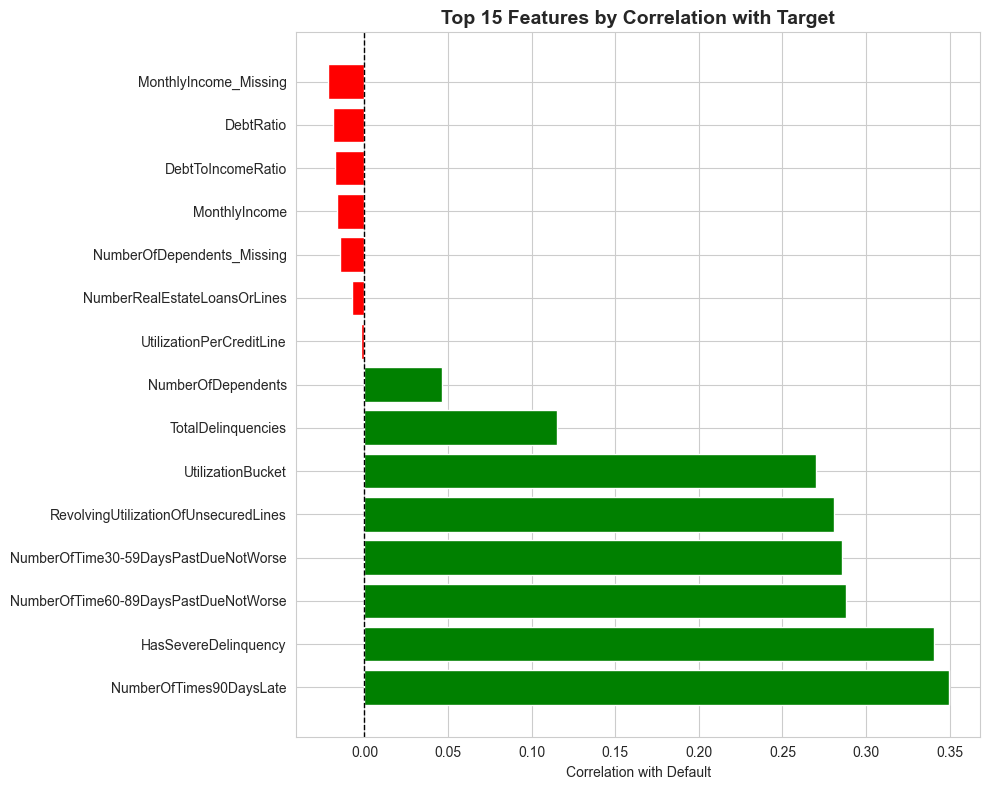

In [27]:
# Visualize top feature correlations
plt.figure(figsize=(10, 8))
top_corr = correlations[1:16]
colors = ['red' if x < 0 else 'green' for x in top_corr]
plt.barh(range(len(top_corr)), top_corr.values, color=colors)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('Correlation with Default')
plt.title('Top 15 Features by Correlation with Target', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

## 10. Final Summary

In [28]:
print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE - SUMMARY")
print("="*60)
print(f"\n1. Original features: {df.shape[1] - 1}")
print(f"2. New features created: {len(new_features)}")
print(f"3. Total features: {X_train_scaled.shape[1]}")
print(f"\n4. Training samples: {X_train_scaled.shape[0]:,}")
print(f"5. Test samples: {X_test_scaled.shape[0]:,}")
print(f"\n6. Class distribution maintained: {(y_train.value_counts(normalize=True) * 100).values[1]:.2f}% defaults")
print(f"\n7. Data saved to: ../data/processed/")
print(f"8. Scaler saved to: ../models/scaler.pkl")

print("\n" + "="*60)
print("✓ READY FOR MODEL TRAINING!")
print("Next: notebooks/03_model_training.ipynb")
print("="*60)


FEATURE ENGINEERING COMPLETE - SUMMARY

1. Original features: 10
2. New features created: 10
3. Total features: 20

4. Training samples: 120,000
5. Test samples: 30,000

6. Class distribution maintained: 6.68% defaults

7. Data saved to: ../data/processed/
8. Scaler saved to: ../models/scaler.pkl

✓ READY FOR MODEL TRAINING!
Next: notebooks/03_model_training.ipynb
